In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
# Set style for better looking plots
plt.style.use('default')
sns.set_palette("husl")


In [2]:
def load_detection_results():
    results = []
    
    with open('models/csv_detection_results.txt', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in lines[2:]:  # Skip header lines
        if line.strip() and '->' in line:
            try:
                # Split by ' -> ' to get the parts
                parts = line.strip().split(' -> ')
                
                if len(parts) >= 4:  # Should have 4 parts: sample, actual, predicted, probabilities
                    # Extract sample number
                    sample_info = parts[0].split()[1]  # "Sample 1" -> "1"
                    
                    # Extract actual label
                    actual_label = parts[1].split(': ')[1]  # "Actual Label: NEGATIVE" -> "NEGATIVE"
                    
                    # Extract predicted label
                    predicted_label = parts[2].split(': ')[1]  # "Predicted Label: NEGATIVE" -> "NEGATIVE"
                    
                    # Extract probabilities
                    prob_part = parts[3]  # "Probabilities: [NEGATIVE: 1.00, NEUTRAL: 0.00, POSITIVE: 0.00]"
                    prob_part = prob_part.replace('Probabilities: ', '')  # Remove prefix
                    prob_part = prob_part.strip('[]')  # Remove brackets
                    
                    probs = {}
                    for prob_item in prob_part.split(', '):
                        if ':' in prob_item:
                            label, prob = prob_item.split(': ')
                            probs[label] = float(prob)
                    
                    results.append({
                        'sample': int(sample_info),
                        'actual': actual_label,
                        'predicted': predicted_label,
                        'probabilities': probs,
                        'confidence': max(probs.values()),
                        'correct': actual_label == predicted_label
                    })
            except Exception as e:
                print(f"Error parsing line: {line.strip()}")
                print(f"Error: {e}")
                continue
    
    return pd.DataFrame(results)


In [3]:
def plot_confusion_matrix(df):
    plt.figure(figsize=(10, 8))
    
    # Create confusion matrix
    cm = confusion_matrix(df['actual'], df['predicted'])
    
    # Plot with seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
                yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
    
    plt.title('Confusion Matrix - Emotion Classification', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()


In [4]:
def plot_accuracy_by_emotion(df):
    plt.figure(figsize=(12, 6))
    
    # Calculate accuracy for each emotion
    emotion_accuracies = {}
    for emotion in df['actual'].unique():
        emotion_data = df[df['actual'] == emotion]
        accuracy = (emotion_data['actual'] == emotion_data['predicted']).mean()
        emotion_accuracies[emotion] = accuracy
    
    # Create bar plot
    emotions = list(emotion_accuracies.keys())
    accuracies = list(emotion_accuracies.values())
    
    bars = plt.bar(emotions, accuracies, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')
    
    plt.title('Classification Accuracy by Emotion', fontsize=16, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/accuracy_by_emotion.png', dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
def plot_confidence_distribution(df):
    plt.figure(figsize=(15, 5))
    
    # Create subplots for each emotion
    emotions = df['actual'].unique()
    
    for i, emotion in enumerate(emotions):
        plt.subplot(1, 3, i+1)
        
        emotion_data = df[df['actual'] == emotion]
        correct_predictions = emotion_data[emotion_data['correct']]
        incorrect_predictions = emotion_data[~emotion_data['correct']]
        
        # Plot histograms
        if len(correct_predictions) > 0:
            plt.hist(correct_predictions['confidence'], alpha=0.7, 
                    label='Correct', color='green', bins=20)
        if len(incorrect_predictions) > 0:
            plt.hist(incorrect_predictions['confidence'], alpha=0.7, 
                    label='Incorrect', color='red', bins=20)
        
        plt.title(f'{emotion} - Confidence Distribution', fontweight='bold')
        plt.xlabel('Confidence Score')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('visualizations/confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
def plot_probability_heatmap(df):
    plt.figure(figsize=(15, 10))
    
    # Extract probability data
    prob_data = []
    for _, row in df.iterrows():
        probs = row['probabilities']
        prob_data.append([probs['NEGATIVE'], probs['NEUTRAL'], probs['POSITIVE']])
    
    prob_matrix = np.array(prob_data)
    
    # Create heatmap
    sns.heatmap(prob_matrix.T, cmap='RdYlBu_r', 
                xticklabels=50, yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
                cbar_kws={'label': 'Probability'})
    
    plt.title('Probability Heatmap - All Samples', fontsize=16, fontweight='bold')
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Emotion Class', fontsize=12)
    plt.tight_layout()
    plt.savefig('visualizations/probability_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
def plot_error_analysis(df):
    plt.figure(figsize=(12, 8))
    
    # Get incorrect predictions
    errors = df[~df['correct']]
    
    if len(errors) == 0:
        print("No errors found! Perfect classification!")
        return
    
    # Create confusion matrix for errors only
    error_matrix = pd.crosstab(errors['actual'], errors['predicted'])
    
    # Plot error confusion matrix
    sns.heatmap(error_matrix, annot=True, fmt='d', cmap='Reds')
    plt.title('Error Analysis - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('visualizations/error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print error statistics
    print(f"\nError Analysis:")
    print(f"Total errors: {len(errors)}")
    print(f"Error rate: {len(errors)/len(df):.2%}")
    
    for actual in errors['actual'].unique():
        actual_errors = errors[errors['actual'] == actual]
        print(f"{actual} errors: {len(actual_errors)}")

In [8]:
def plot_emotion_distribution(df):
    plt.figure(figsize=(15, 6))
    
    # Actual distribution
    plt.subplot(1, 2, 1)
    actual_counts = df['actual'].value_counts()
    plt.pie(actual_counts.values, labels=actual_counts.index, autopct='%1.1f%%',
            colors=['#ff6b6b', '#4ecdc4', '#45b7d1'])
    plt.title('Actual Emotion Distribution', fontweight='bold')
    
    # Predicted distribution
    plt.subplot(1, 2, 2)
    predicted_counts = df['predicted'].value_counts()
    plt.pie(predicted_counts.values, labels=predicted_counts.index, autopct='%1.1f%%',
            colors=['#ff6b6b', '#4ecdc4', '#45b7d1'])
    plt.title('Predicted Emotion Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('visualizations/emotion_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
def plot_confidence_vs_accuracy(df):
    plt.figure(figsize=(12, 6))
    
    # Create confidence bins
    df['confidence_bin'] = pd.cut(df['confidence'], bins=10)
    
    # Calculate accuracy for each confidence bin
    bin_accuracy = df.groupby('confidence_bin')['correct'].mean()
    bin_counts = df.groupby('confidence_bin').size()
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Accuracy vs Confidence
    bin_accuracy.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title('Accuracy vs Confidence Bins', fontweight='bold')
    ax1.set_xlabel('Confidence Bins')
    ax1.set_ylabel('Accuracy')
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Sample count vs Confidence
    bin_counts.plot(kind='bar', ax=ax2, color='lightcoral')
    ax2.set_title('Sample Count vs Confidence Bins', fontweight='bold')
    ax2.set_xlabel('Confidence Bins')
    ax2.set_ylabel('Number of Samples')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('visualizations/confidence_vs_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
def create_summary_report(df):
    print("=" * 60)
    print("EEG EMOTION CLASSIFICATION - SUMMARY REPORT")
    print("=" * 60)
    
    # Overall statistics
    total_samples = len(df)
    correct_predictions = df['correct'].sum()
    accuracy = correct_predictions / total_samples
    
    print(f"\nOVERALL PERFORMANCE:")
    print(f"   Total samples: {total_samples}")
    print(f"   Correct predictions: {correct_predictions}")
    print(f"   Overall accuracy: {accuracy:.2%}")
    
    # Per-emotion statistics
    print(f"\nPER-EMOTION PERFORMANCE:")
    for emotion in df['actual'].unique():
        emotion_data = df[df['actual'] == emotion]
        emotion_accuracy = (emotion_data['actual'] == emotion_data['predicted']).mean()
        emotion_count = len(emotion_data)
        print(f"   {emotion}: {emotion_accuracy:.2%} accuracy ({emotion_count} samples)")
    
    # Confidence statistics
    print(f"\nCONFIDENCE STATISTICS:")
    print(f"   Average confidence: {df['confidence'].mean():.3f}")
    print(f"   Median confidence: {df['confidence'].median():.3f}")
    print(f"   Confidence std: {df['confidence'].std():.3f}")
    
    # High confidence predictions
    high_conf = df[df['confidence'] > 0.9]
    if len(high_conf) > 0:
        high_conf_accuracy = high_conf['correct'].mean()
        print(f"   High confidence (>0.9) accuracy: {high_conf_accuracy:.2%}")
        print(f"   High confidence samples: {len(high_conf)}")
    
    print("\n" + "=" * 60)


Loading detection results...
Loaded 2132 prediction results

Creating visualizations...
EEG EMOTION CLASSIFICATION - SUMMARY REPORT

OVERALL PERFORMANCE:
   Total samples: 2132
   Correct predictions: 2041
   Overall accuracy: 95.73%

PER-EMOTION PERFORMANCE:
   NEGATIVE: 98.45% accuracy (708 samples)
   NEUTRAL: 98.74% accuracy (716 samples)
   POSITIVE: 89.97% accuracy (708 samples)

CONFIDENCE STATISTICS:
   Average confidence: 0.958
   Median confidence: 1.000
   Confidence std: 0.107
   High confidence (>0.9) accuracy: 99.72%
   High confidence samples: 1807



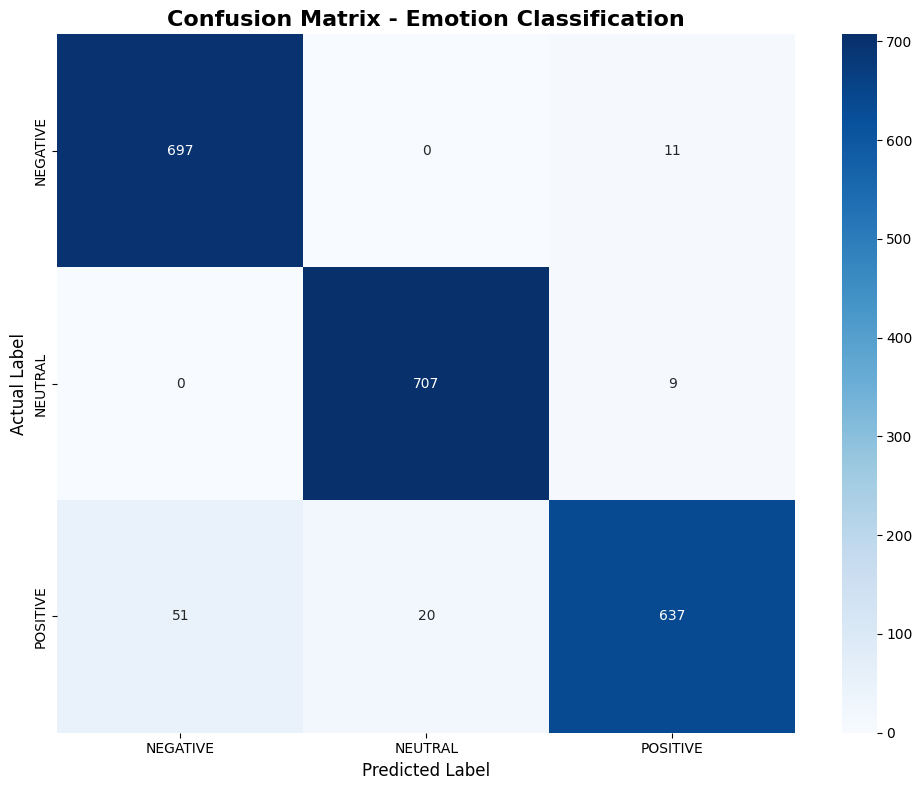

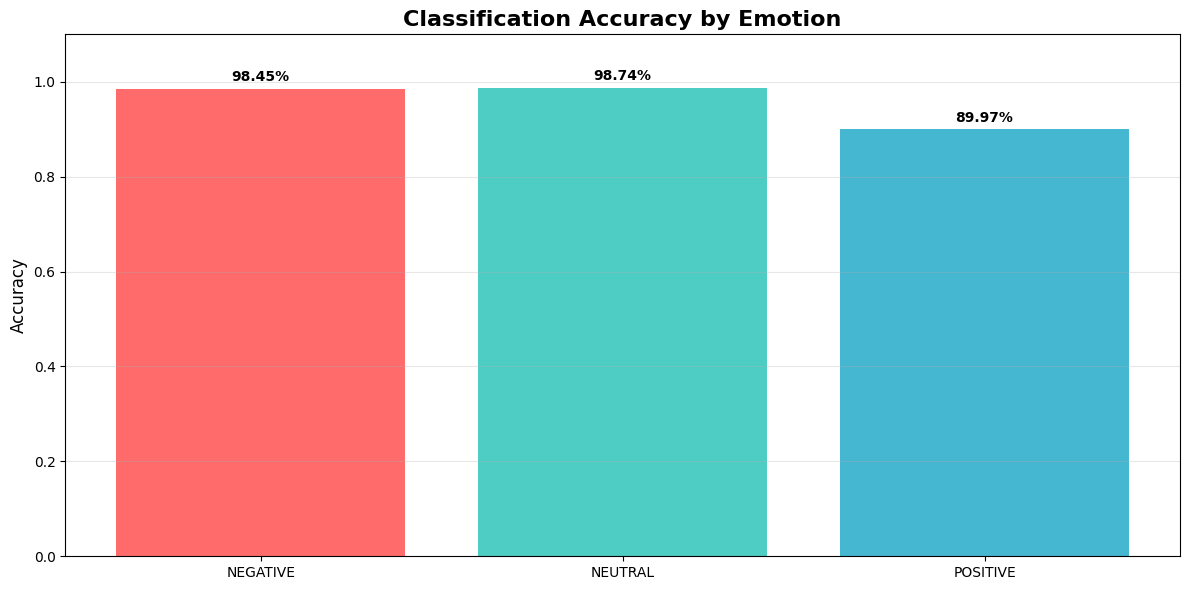

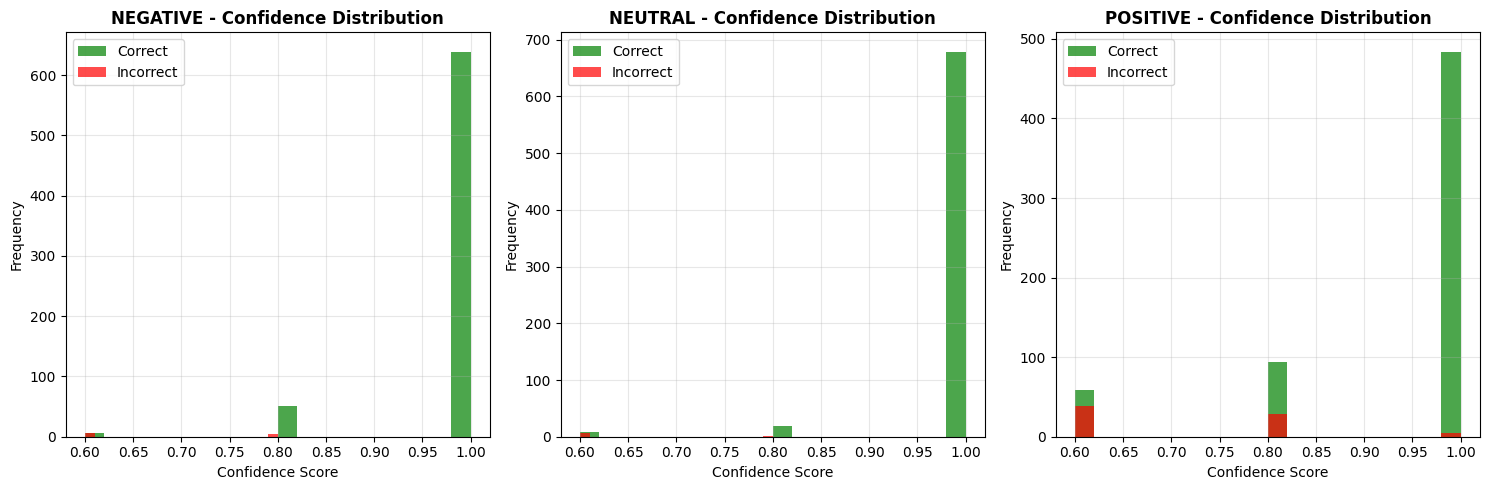

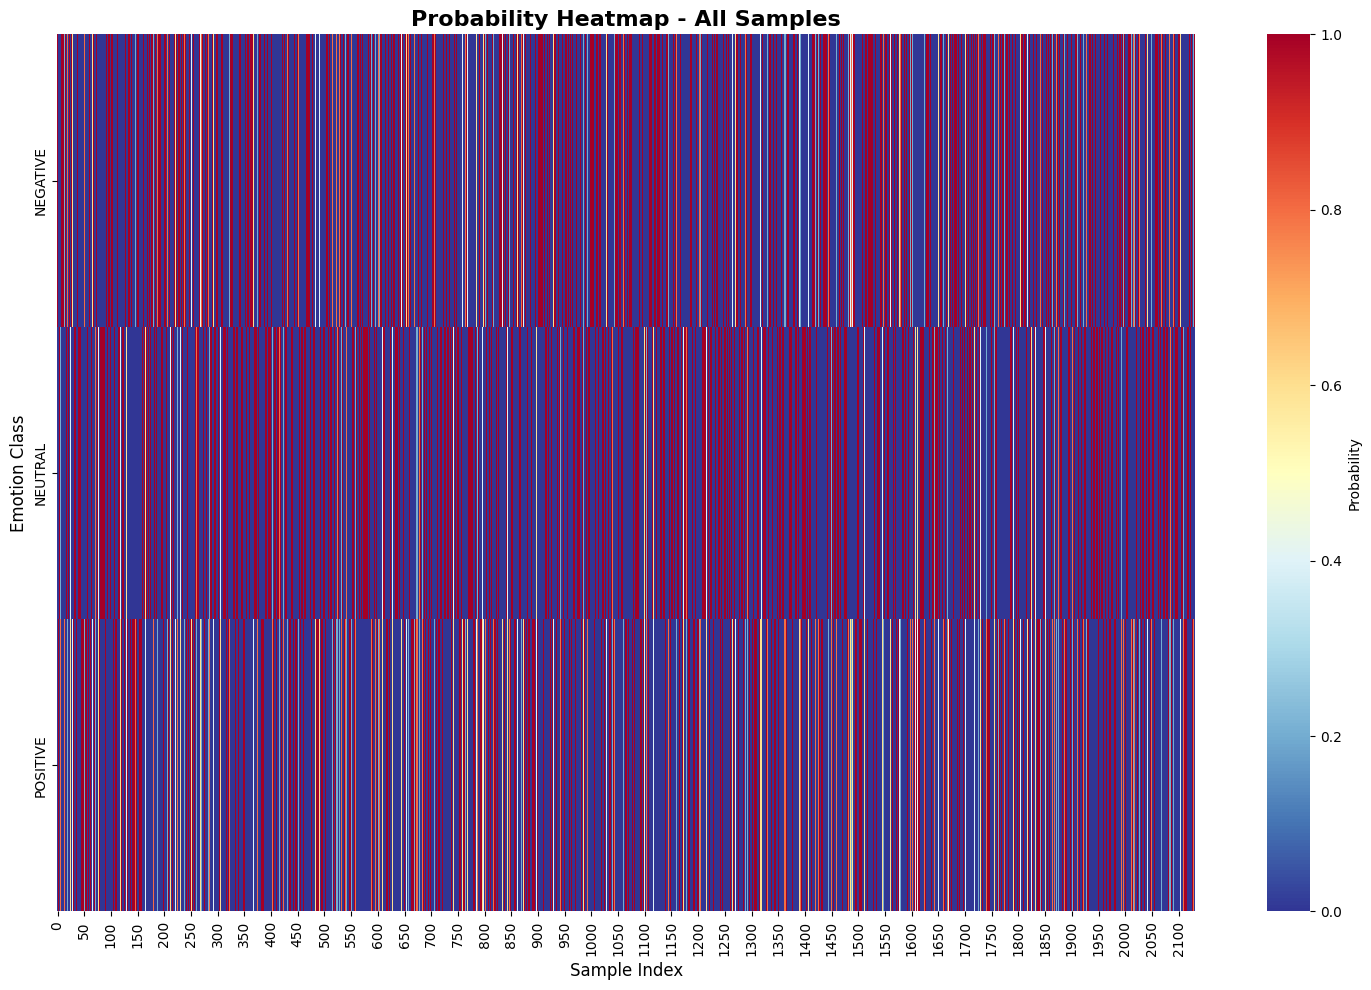

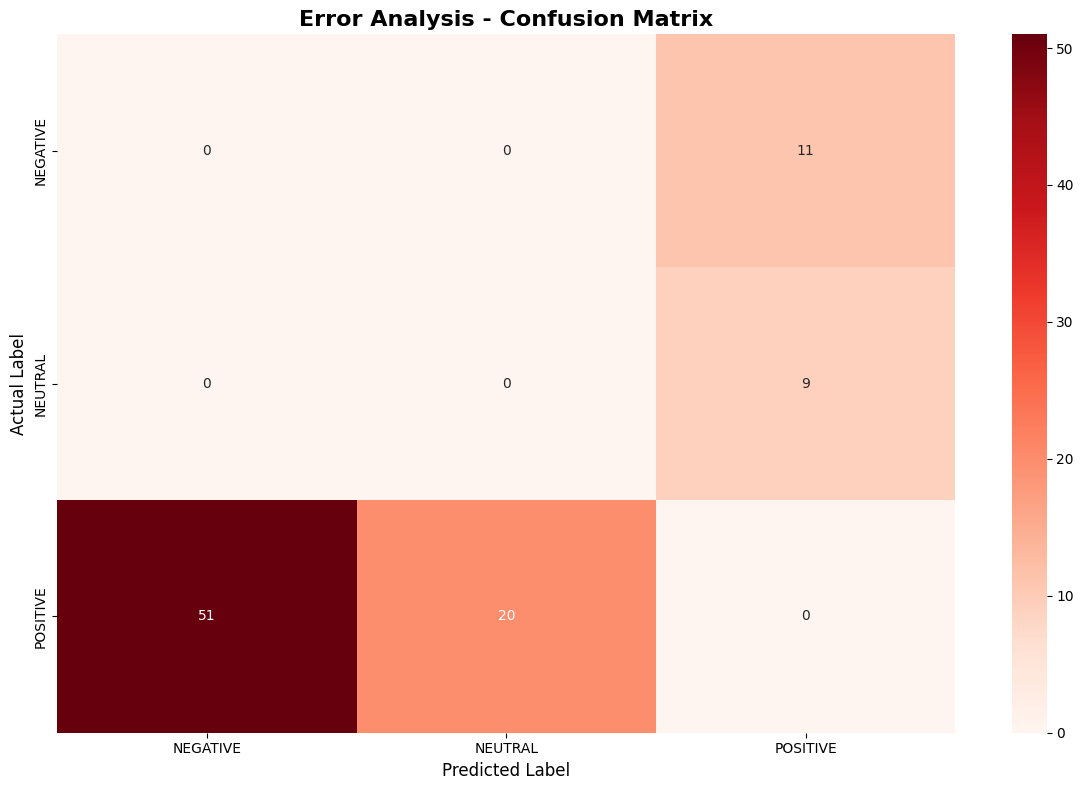


Error Analysis:
Total errors: 91
Error rate: 4.27%
NEGATIVE errors: 11
POSITIVE errors: 71
NEUTRAL errors: 9


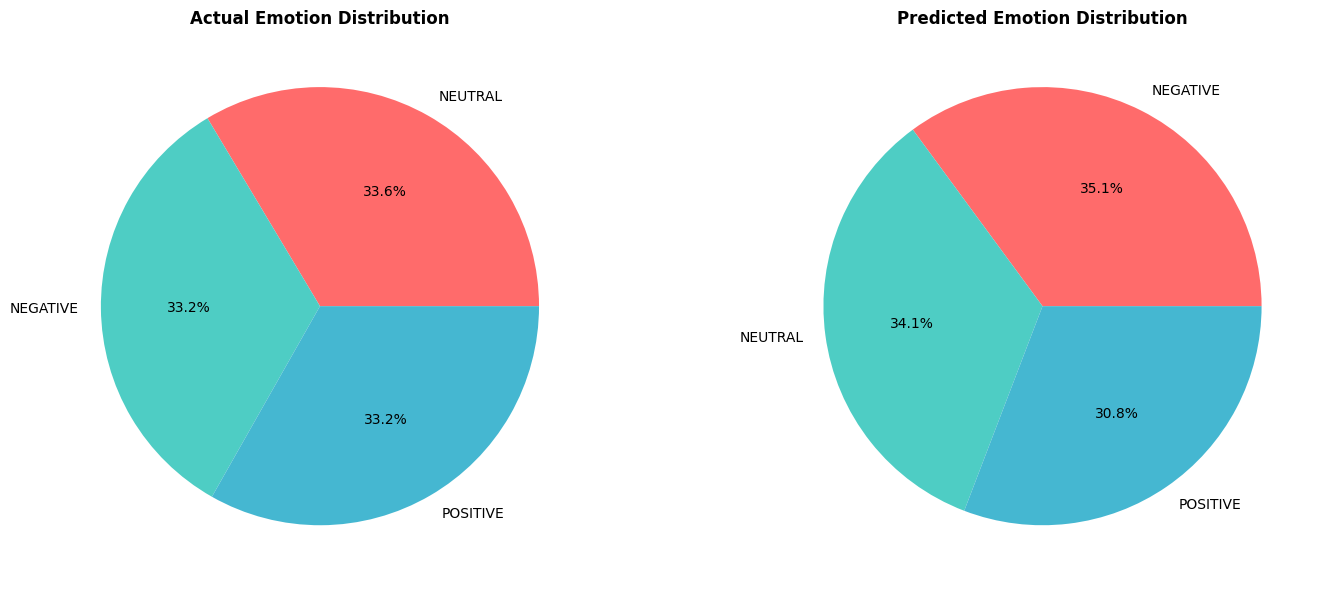

<Figure size 1200x600 with 0 Axes>

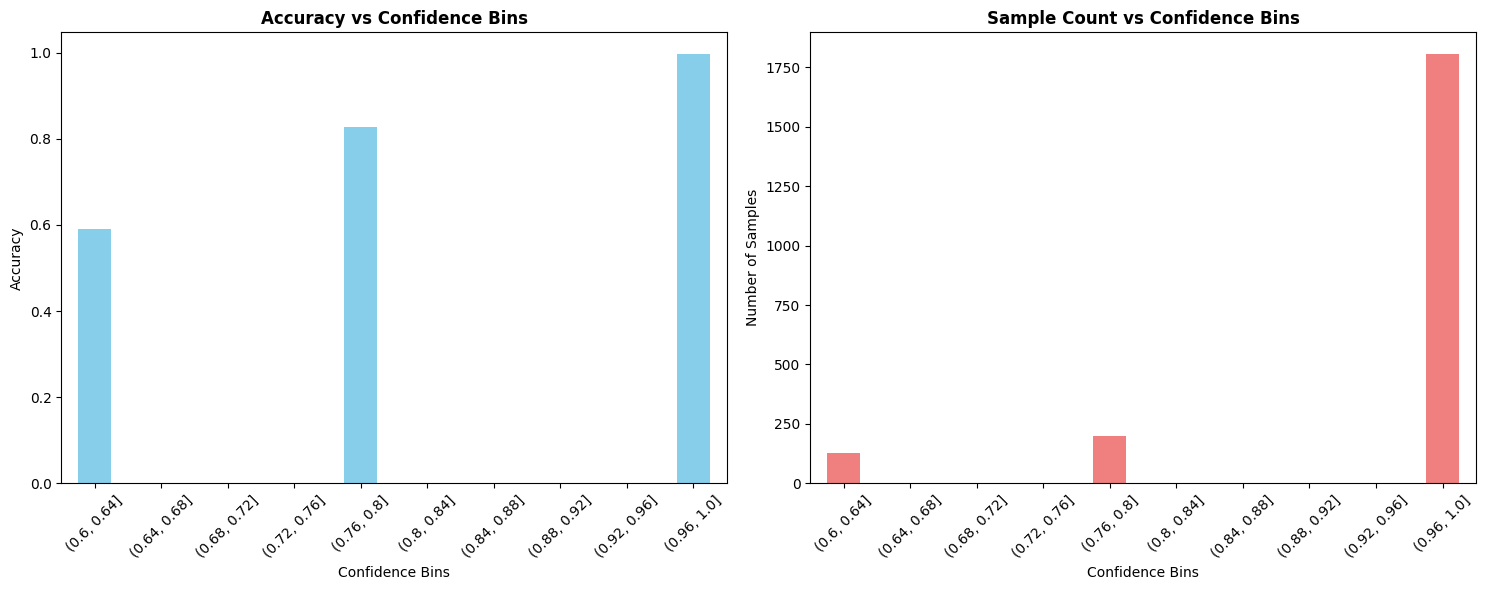


All visualizations saved to 'visualizations/' directory!
 Generated files:
   - confusion_matrix.png
   - accuracy_by_emotion.png
   - confidence_distribution.png
   - probability_heatmap.png
   - error_analysis.png
   - emotion_distribution.png
   - confidence_vs_accuracy.png


In [11]:
def main():
    # Create visualizations directory
    import os
    os.makedirs('visualizations', exist_ok=True)
    
    print("Loading detection results...")
    df = load_detection_results()
    
    if df.empty:
        print("No results found! Please run detect.py first.")
        return
    
    print(f"Loaded {len(df)} prediction results")
    
    print("\nCreating visualizations...")
    
    create_summary_report(df)
    
    plot_confusion_matrix(df)
    plot_accuracy_by_emotion(df)
    plot_confidence_distribution(df)
    plot_probability_heatmap(df)
    plot_error_analysis(df)
    plot_emotion_distribution(df)
    plot_confidence_vs_accuracy(df)
    
    print(f"\nAll visualizations saved to 'visualizations/' directory!")
    print(" Generated files:")
    print("   - confusion_matrix.png")
    print("   - accuracy_by_emotion.png")
    print("   - confidence_distribution.png")
    print("   - probability_heatmap.png")
    print("   - error_analysis.png")
    print("   - emotion_distribution.png")
    print("   - confidence_vs_accuracy.png")

if __name__ == "__main__":
    main() 